# Introduction to Recommender Systems

<p align="center">
    <img width="721" alt="cover-image" src="https://user-images.githubusercontent.com/49638680/204351915-373011d3-75ac-4e21-a6df-99cd1c552f2c.png">
</p>

---

# Non-Personalised Recommendations

Let's introduce a non-personalised recommendation system. Before proceeding let's point out the reasons for the non-personalised recommendations:

1. New users: we know little about them (_cold-start_ problem).
2. Simple implementation but beneficial.
3. Communities share the same behaviour, hence same recommendations.
4. Applications to cases where personalised recommendations are impossible.

As an example, think about the weekly review of books or restaurants on newspaper articles.
These are also called __stereotyped recommender system__.

## A code implementation of a non-personalised recommendation system

The aim of this notebook is to provide an implementation of a non-personalised recommendation system.


In [72]:
# Import libraries
import sys
import numpy as np
import pandas as pd
from typing import List
from scipy.sparse import csr_matrix

from pathlib import Path

src_root = Path("..").resolve()
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

from utils import non_pers_rec as npr
from utils.data_utils import load_data
from tests.non_pers_tests import test_get_recent_liked_movie, test_get_movie_genre

import matplotlib.pyplot as plt
import seaborn as sns

# set plot size
plt.rcParams["figure.figsize"] = (20, 13)
sns.set_theme()
%matplotlib inline
%config InlineBackend.figure_format = "retina"

We are going to use only **NumPy** to build a recommender for users who have **not rated any movies**, by suggesting the **most popular movie** in the catalogue.

---

### **📝 Step 1: Choose Your Dataset Version**
The data comes from the famous [MovieLens dataset](https://grouplens.org/datasets/movielens/).  
Different versions exist depending on the dataset size:

| **Dataset**       | **Size** | **Ratings** | **Use Case** |
|------------------|---------|------------|--------------|
| **MovieLens 100K** | Small   | 100,000    | Best for quick experiments |
| **MovieLens 1M**  | Medium  | 1,000,000  | Good balance between size & complexity |
| **MovieLens 20M** | Large   | 20,000,000 | More realistic, requires optimisation |

👉 **Choose which dataset version you want to use!**  

---

### **📝 Step 2: Download the Dataset (Write a Bash Command)**
Before we proceed, you need to **write a Bash command** to download the dataset you selected.  
Use `wget` or `curl` to download the `.zip` file from the [MovieLens website](https://grouplens.org/datasets/movielens/).

#### **🔧 Task: Write the Bash command below**
- If using **MovieLens 100K**, download:  
  `http://files.grouplens.org/datasets/movielens/ml-100k.zip`
- If using **MovieLens 1M**, download:  
  `http://files.grouplens.org/datasets/movielens/ml-1m.zip`
- If using **MovieLens 20M**, download:  
  `http://files.grouplens.org/datasets/movielens/ml-20m.zip`

💡 **Hint:** The following commands might be useful:
```bash
wget
unzip -o
```

In [73]:
%%bash
mkdir -p ../../data/movielens_100k
wget -O /tmp/ml-100k.zip \
  https://files.grouplens.org/datasets/movielens/ml-100k.zip
unzip -o /tmp/ml-100k.zip -d ../../data/movielens_100k

--2026-09-18 10:05:34--  https://files.grouplens.org/datasets/movielens/ml-100k.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4924029 (4.7M) [application/zip]
Saving to: ‘/tmp/ml-100k.zip’

     0K .......... .......... .......... .......... ..........  1%  222K 21s
    50K .......... .......... .......... .......... ..........  2%  450K 16s
   100K .......... .......... .......... .......... ..........  3% 14.3M 11s
   150K .......... .......... .......... .......... ..........  4%  102M 8s
   200K .......... .......... .......... .......... ..........  5%  268K 10s
   250K .......... .......... .......... .......... ..........  6%  384M 8s
   300K .......... .......... .......... .......... ..........  7% 50.8M 7s
   350K .......... .......... .......... .......... ..........  8%  186M 6s
   400K .......... ......

Archive:  /tmp/ml-100k.zip
  inflating: ../data/movielens_100k/ml-100k/allbut.pl  
  inflating: ../data/movielens_100k/ml-100k/mku.sh  
  inflating: ../data/movielens_100k/ml-100k/README  
  inflating: ../data/movielens_100k/ml-100k/u.data  
  inflating: ../data/movielens_100k/ml-100k/u.genre  
  inflating: ../data/movielens_100k/ml-100k/u.info  
  inflating: ../data/movielens_100k/ml-100k/u.item  
  inflating: ../data/movielens_100k/ml-100k/u.occupation  
  inflating: ../data/movielens_100k/ml-100k/u.user  
  inflating: ../data/movielens_100k/ml-100k/u1.base  
  inflating: ../data/movielens_100k/ml-100k/u1.test  
  inflating: ../data/movielens_100k/ml-100k/u2.base  
  inflating: ../data/movielens_100k/ml-100k/u2.test  
  inflating: ../data/movielens_100k/ml-100k/u3.base  
  inflating: ../data/movielens_100k/ml-100k/u3.test  
  inflating: ../data/movielens_100k/ml-100k/u4.base  
  inflating: ../data/movielens_100k/ml-100k/u4.test  
  inflating: ../data/movielens_100k/ml-100k/u5.base  


Let's now import such big data structures into dataframes.

**Careful!** This can take some time.

In [74]:
data_path = "../../data/movielens_100k/ml-100k"
rating_columns = ["UserId", "MovieId", "Rating", "Timestamp"]

df_rating = pd.read_csv(
    f"{data_path}/u1.base",
    sep="\t",
    engine="python",
    header=None,
    names=rating_columns,
)
df_rating_test = pd.read_csv(
    f"{data_path}/u1.test",
    sep="\t",
    engine="python",
    header=None,
    names=rating_columns,
)

df_users = pd.read_csv(
    f"{data_path}/u.user",
    sep="|",
    engine="python",
    header=None,
    names=["UserId", "Age", "Gender", "Occupation", "ZipCode"],
)
df_users.set_index("UserId", inplace=True)

item_columns = [
    "MovieId", "Title", "Date", "VideoReleaseDate", "Url", "unknown",
    "Action", "Adventure", "Animation", "Children", "Comedy", "Crime",
    "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror", "Musical",
    "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western",
]
df_items = pd.read_csv(
    f"{data_path}/u.item",
    sep="|",
    engine="python",
    encoding="ISO-8859-1",
    header=None,
    names=item_columns,
)
df_items.set_index("MovieId", inplace=True)

In [75]:
df_rating.head()

,UserId,MovieId,Rating,Timestamp
0,1,1,5,874965758
1,1,2,3,876893171
2,1,3,4,878542960
3,1,4,3,876893119
4,1,5,3,889751712


In [76]:
df_rating.info(
    memory_usage="deep"
)  # memory_usage parameter allows us to see the real memory usage

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   UserId     80000 non-null  int64
 1   MovieId    80000 non-null  int64
 2   Rating     80000 non-null  int64
 3   Timestamp  80000 non-null  int64
dtypes: int64(4)
memory usage: 2.4 MB


We can see that the dataframe is simply too large to be handled properly. 
There is a variety of possible solutions to face such an issue.

### 📝 Exercise: Reducing the MovieLens Dataset for Efficient Analysis
#### 📌 Problem Statement:
The MovieLens dataset, even at 100K, can be heavy to process.
To make analysis and modelling more efficient, we need to reduce its size while preserving meaningful patterns.

#### 📌 Task
You will apply data reduction techniques to make the dataset lighter while ensuring that it still represents real-world patterns.

**1️⃣ Define a Reduction Strategy**
How can we reduce the dataset while maintaining its usefulness for building a recommender system?
👉 Possible strategies to consider:

Filter out inactive users (users who rated very few movies).
Remove rarely rated movies (movies with very few ratings).
Sample a subset of users & their interactions.
**❓ Think About**: What are the pros and cons of each approach?

---

**2️⃣ Implement the Reduction**
👉 Modify the dataset using Pandas to:

Keep only users who have rated at least 20 movies.
Keep only movies that have received at least 50 ratings.
💡 Hint: You might need to use `.groupby()` and `.filter()` methods.

### Réponse — choix de la stratégie de réduction

- **Retirer les utilisateurs peu actifs** rend les profils plus fiables et réduit le nombre de valeurs manquantes. En revanche, cela écarte les nouveaux utilisateurs et les utilisateurs occasionnels.
- **Retirer les films très peu notés** donne des statistiques plus solides et accélère les calculs. Le risque est de perdre des films de niche qui pourraient pourtant intéresser certains utilisateurs.
- **Prendre un échantillon aléatoire** est simple et rapide. Il faut toutefois fixer une graine aléatoire et, si possible, faire un échantillonnage équilibré pour ne pas supprimer par hasard certains types d'utilisateurs ou de films.

Ici, les seuils de 20 notes par utilisateur et de 50 notes par film représentent un compromis : le jeu devient beaucoup plus léger, mais il est aussi davantage centré sur les utilisateurs actifs et les films populaires.

In [77]:
# 📝 **TASK:** Reduce the dataset following the strategy above.

# Step 1: Count how many ratings each movie received
movie_rating_counts = df_rating.groupby("MovieId").size()

# Step 2: Count how many ratings each user gave
user_rating_counts = df_rating.groupby("UserId").size()

# Step 3: Apply filters to keep only active users and popular movies
df_rating_before_reduction = df_rating.copy()
active_users = user_rating_counts[user_rating_counts >= 20].index
popular_movies = movie_rating_counts[movie_rating_counts >= 50].index
df_rating_reduced = df_rating[
    df_rating["UserId"].isin(active_users)
    & df_rating["MovieId"].isin(popular_movies)
].copy()

# Step 4: Display the new dataset size
print(f"Dataset reduced from {df_rating_before_reduction.shape} to {df_rating_reduced.shape}")

Dataset reduced from (80000, 4) to (62459, 4)


**3️⃣ Evaluate the Effect of Reduction**
Once you've filtered the dataset:

Compare the number of users and movies before and after.
Check if the average rating distribution has changed.

Before reduction: (80000, 4)
After reduction: (62459, 4)


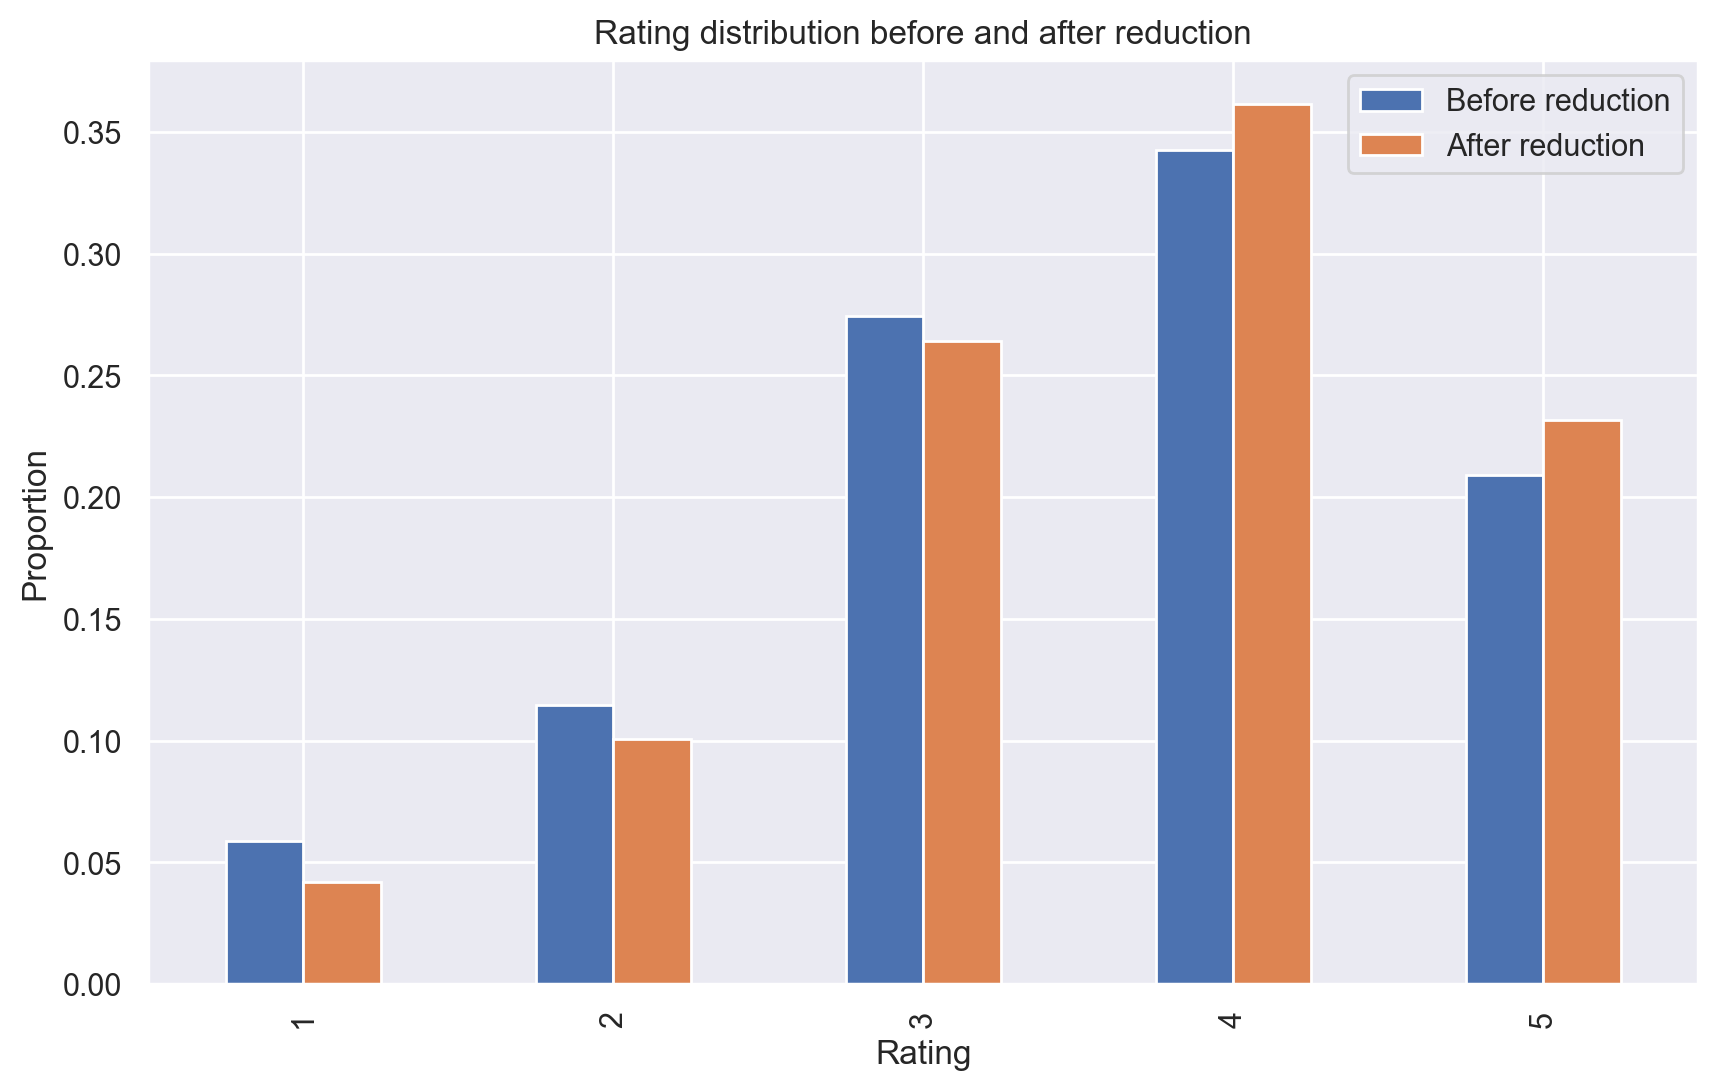

In [78]:
# 📝 **TASK:** Compare dataset size before and after reduction.

# Step 1: Print the shape of df_rating before reduction
print("Before reduction:", df_rating_before_reduction.shape)

# Step 2: Print the shape of df_rating after reduction
print("After reduction:", df_rating_reduced.shape)

# Step 3: Plot the rating distribution to see if it's still representative
rating_distributions = pd.DataFrame({
    "Before reduction": df_rating_before_reduction["Rating"].value_counts(normalize=True),
    "After reduction": df_rating_reduced["Rating"].value_counts(normalize=True),
}).sort_index()
rating_distributions.plot(kind="bar", figsize=(10, 6))
plt.xlabel("Rating")
plt.ylabel("Proportion")
plt.title("Rating distribution before and after reduction")
plt.show()

### Vérification du filtrage

Le jeu d'origine contient **80 000 notes**, données par **943 utilisateurs** sur **1 650 films notés**. Après application des deux seuils, il reste **62 459 notes**, **834 utilisateurs** et **525 films**.

La note moyenne passe de **3,53** à **3,64**. La distribution reste proche de celle d'origine, mais le filtre renforce légèrement la part des bonnes notes : les films populaires ont tendance à être mieux notés. La réduction est donc utile pour les performances, mais elle introduit un petit biais en faveur des films connus.

#### Further approaches

**❓ Think About**: What other strategies could you use to reduce the dataset?

After completing the main exercise, try:

- Reducing by random sampling instead of filtering.
- Removing users who only gave extreme ratings (only 1s and 5s).
- Keeping only users from a specific age group or occupation.

### Réponse — autres méthodes possibles

On pourrait aussi :

- garder seulement une période récente pour mieux représenter les goûts actuels ;
- faire un échantillonnage équilibré selon l'activité des utilisateurs, les genres ou les notes ;
- appliquer un filtrage *k-core* de façon répétée, jusqu'à ce que chaque utilisateur et chaque film possède un nombre minimum d'interactions ;
- limiter le nombre de notes par utilisateur très actif, afin qu'une petite minorité ne domine pas le jeu de données.

Supprimer les utilisateurs qui donnent uniquement des notes extrêmes peut réduire le bruit, mais il faut rester prudent : certains utilisateurs ont réellement des avis très tranchés.

In [79]:
# Import data from movielens dataset

In order to compose the training data as we have seen in lectures, we need to create a matrix having users in rows and movies in columns (or its equivalent transpose matrix).

This can be easily done by a pivot operator in pandas.

In [80]:
df_rating.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   UserId     80000 non-null  int64
 1   MovieId    80000 non-null  int64
 2   Rating     80000 non-null  int64
 3   Timestamp  80000 non-null  int64
dtypes: int64(4)
memory usage: 2.4 MB


### 📝 Exercise: Transform Ratings Table into a User-Movie Matrix

#### 📌 Goal:
Convert the ratings table into a user-movie matrix, where:

Rows represent users
Columns represent movies
Cells contain ratings, with NaN where users have not rated the movie
--- 

#### 🎯 Your Task
1. **Understand the Structure of the Data**
Use `.head()` to inspect the ratings DataFrame.
Identify which columns will be used to pivot the data.

2. **Transform the Ratings Table**
Use pivot() or pivot_table() in Pandas to reshape the DataFrame.
Ensure that:
Users are in rows (index="UserId")
Movies are in columns (columns="MovieId")
Ratings are filled in (values="Rating")
Handle missing ratings by keeping NaN for unwatched movies.

3. **Check the New Matrix**
Print the shape of the matrix.
Display the first few rows.

---

❓ Think About
Why do we keep NaN instead of filling with zeros?
How can we later use this matrix in a recommender system?
What happens if a user or a movie has no ratings?

---

💡 Tips
Use the pivot_table() function to handle potential duplicate entries.
Consider using the fill_value parameter to handle missing values.

---

🚀 Bonus Challenge
Modify the matrix to fill NaN values with the movie's average rating instead of keeping NaNs.


### Réponse — valeurs manquantes dans la matrice

- On garde `NaN` parce qu'il signifie **« l'utilisateur n'a pas noté ce film »**. Mettre `0` serait trompeur : l'échelle va de 1 à 5 et le modèle pourrait comprendre que l'utilisateur déteste le film.
- Cette matrice pourra servir à calculer des ressemblances entre utilisateurs ou entre films, ou à entraîner un modèle de factorisation de matrice. Les algorithmes doivent simplement ignorer les cases inconnues pendant l'apprentissage.
- Un utilisateur sans aucune note correspond au problème du **démarrage à froid**. On peut alors proposer les films populaires ou lui demander quelques préférences. Pour un film sans note, on peut utiliser son genre, son réalisateur ou d'autres informations de contenu.

Remplacer les `NaN` par la moyenne du film est possible, mais cela invente beaucoup de valeurs et rend les utilisateurs artificiellement semblables. Il vaut mieux le faire seulement si l'algorithme choisi exige une matrice complète.

In [81]:
# Insert your code here
df_matrix = df_rating.pivot_table(
    index="UserId",
    columns="MovieId",
    values="Rating",
    aggfunc="mean",
)
n_users, n_items = df_matrix.shape
print(f"User-movie matrix shape: {df_matrix.shape}")
df_matrix.head()

User-movie matrix shape: (943, 1650)


MovieId,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
UserId,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,NaN,4.0,1.0,5.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [82]:
df_matrix

MovieId,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
UserId,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,NaN,4.0,1.0,5.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
939,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
940,NaN,NaN,NaN,2.0,NaN,NaN,4.0,5.0,3.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
941,5.0,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


As one can see, the matrix is full of nan values.

## Exploratory data analysis

Let's have a look at the data, just to get some insights that will help us in the rest of the course.

### Rating distribution

First of all, we want to study the distributions of all ratings. This is useful to see whether in our database we have a particularly unbalanced rating, or if on average all movies are equally appreciated.

There are several ways to do so, all enlightening a slightly different aspect of the data. 
Recall that the rating matrix is _sparse_ (_i.e._ plenty of nan's).

Consider the following,

1. **Histograms**: You can plot a histogram of the non-zero values in your sparse matrix to see their distribution.

2. **Density plots**: Another way to visualize the distribution of values in a sparse matrix is to plot a density plot, which is a smoothed version of a histogram.

3. **Box plots**: A box plot can give you a good idea of the distribution of values in your sparse matrix, especially if you have a large number of non-zero values.

4. **Scatter plots**: You can also plot the non-zero values in your sparse matrix as a scatter plot, which can give you an idea of the distribution and relationship between different values.

Let's look at the density plot (we leave the other plots as exercise).

/var/folders/q7/88jnc13j4tv61tmxd55fkwn00000gn/T/ipykernel_67285/3042612249.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(non_zero_values.data, shade=True)


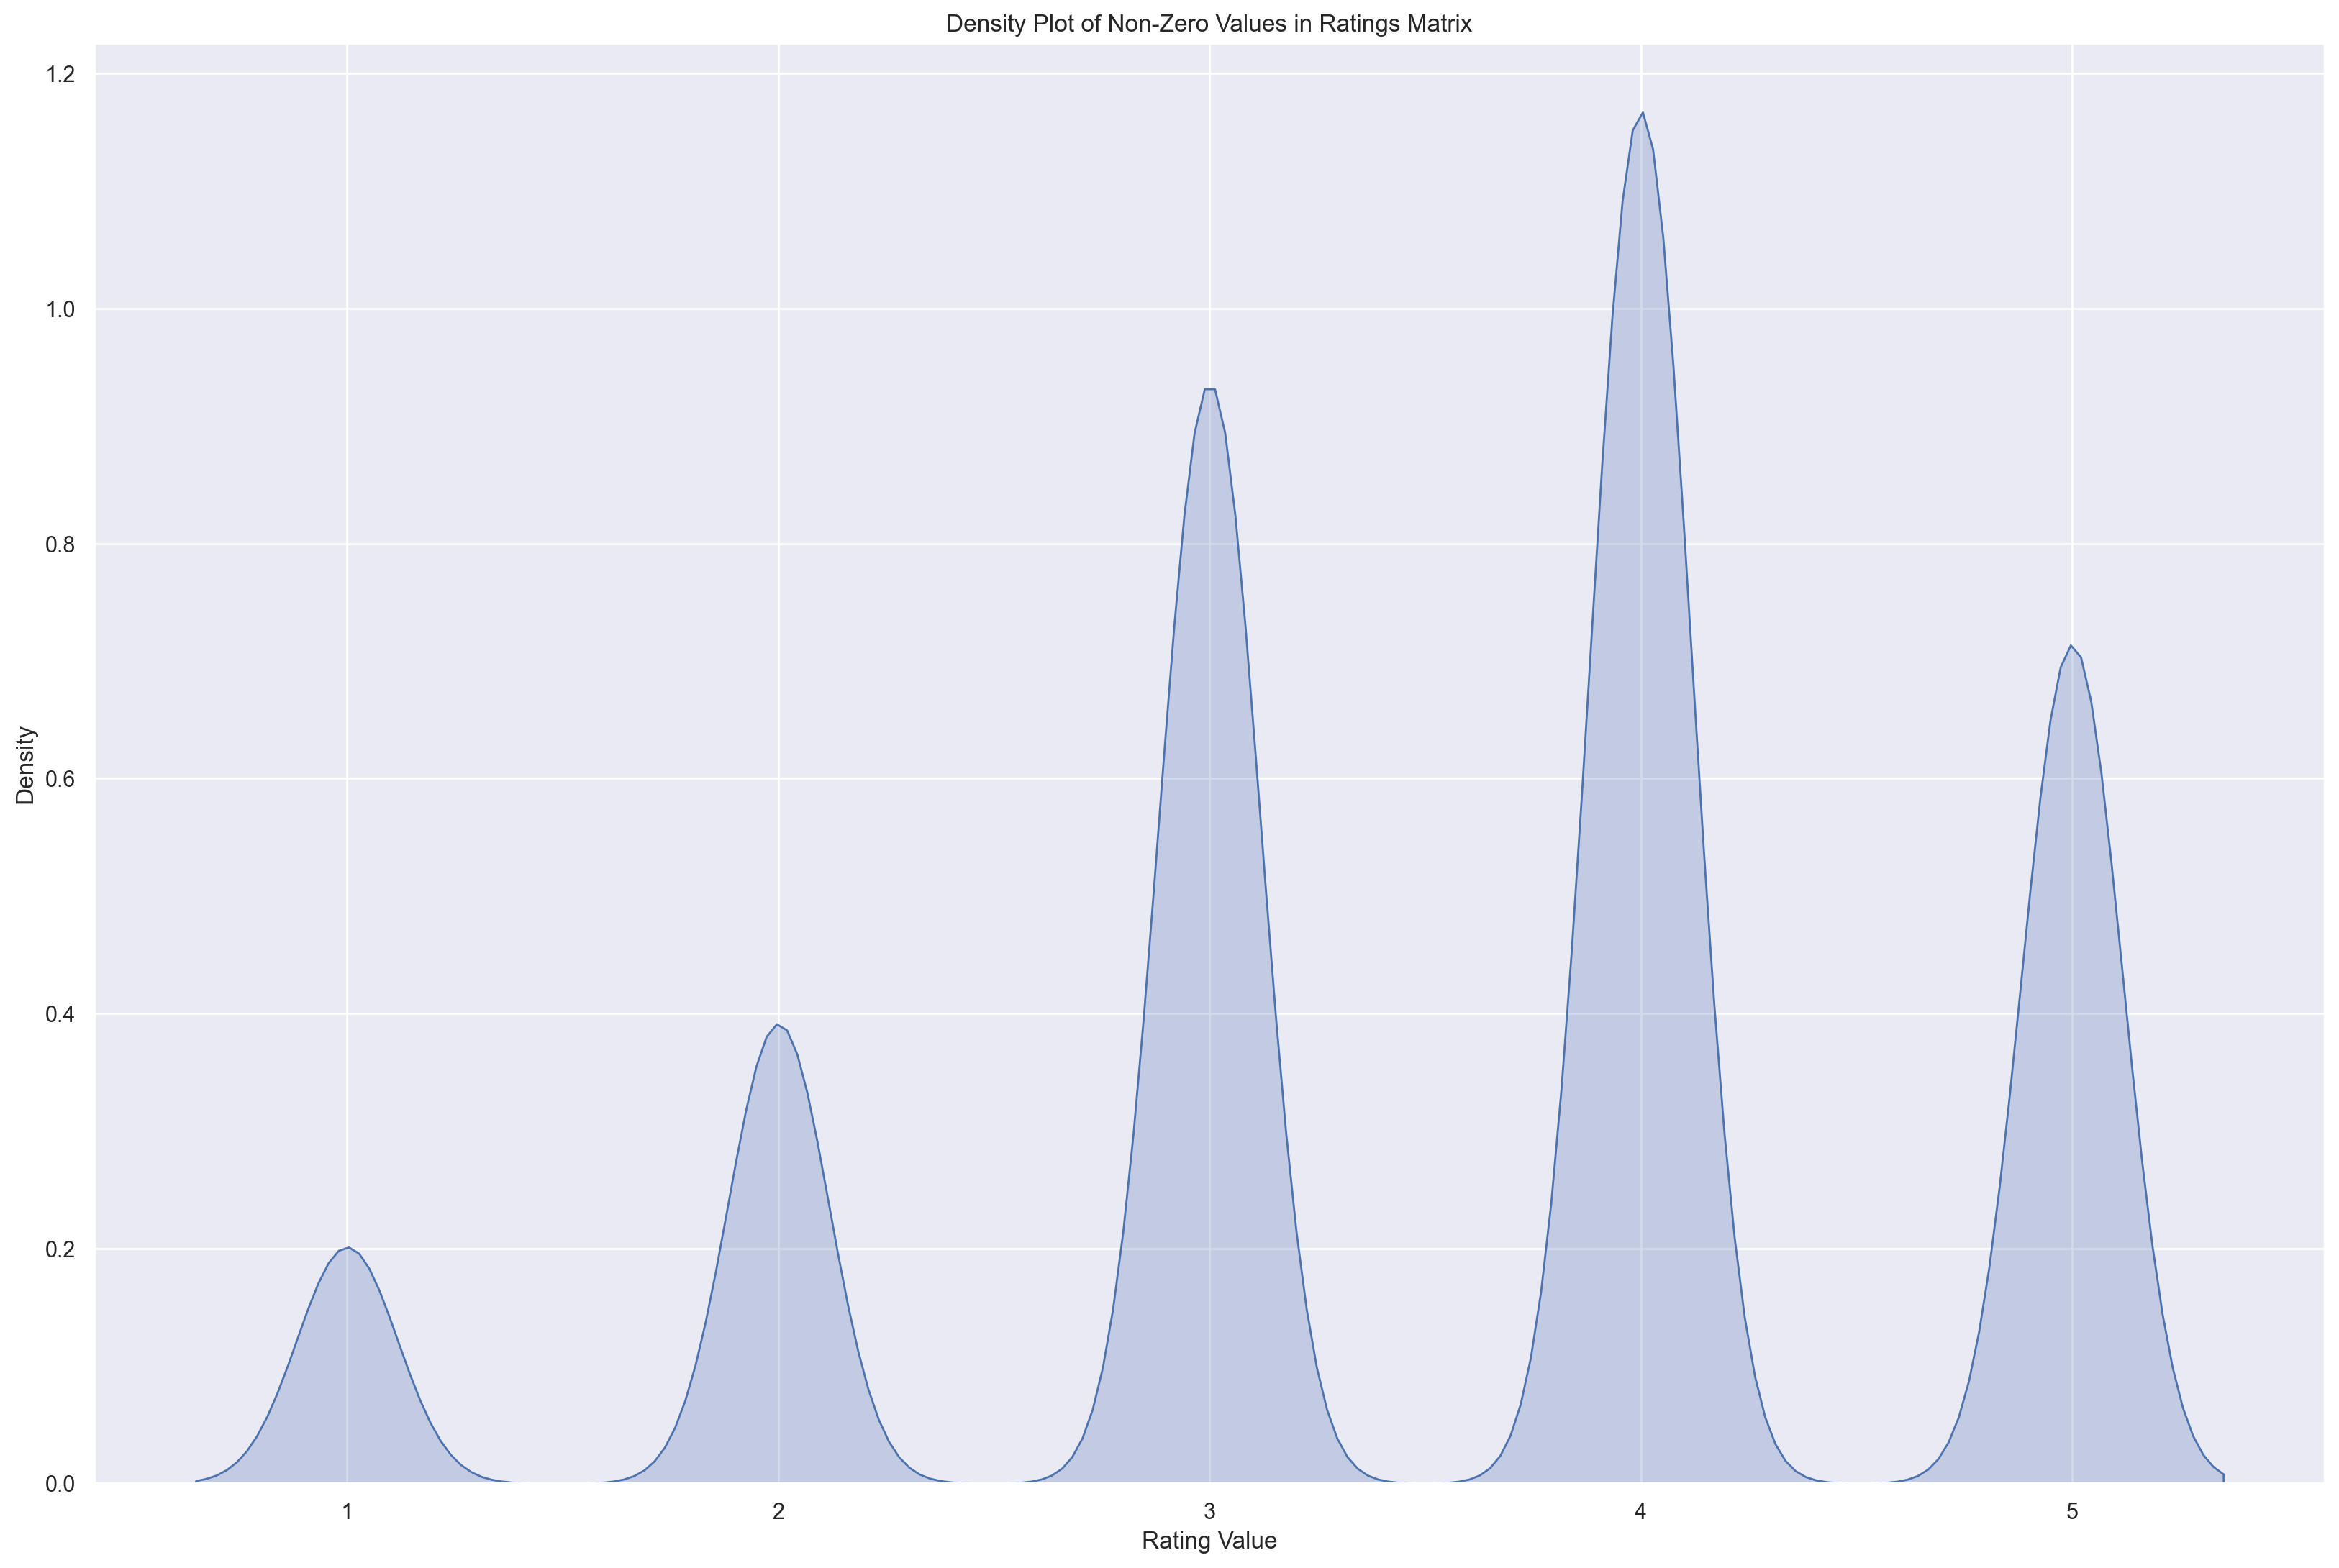

In [83]:
non_zero_values = csr_matrix(df_matrix.T.fillna(0).values)

# Plot the density plot of the non-zero values
sns.kdeplot(non_zero_values.data, shade=True)

# Add a title and labels to the plot
plt.title("Density Plot of Non-Zero Values in Ratings Matrix")
plt.xlabel("Rating Value")
plt.ylabel("Density")

# Show the plot
plt.show()

### Explaining the Density Plot of the Ratings Matrix
#### 1️⃣ What Are We Plotting?
In this density plot, we visualise the distribution of ratings (excluding NaNs) in the user-movie matrix.

The x-axis represents rating values (e.g., 1–5).
The y-axis represents the density (relative frequency of ratings).
The curve shows how common each rating is in the dataset.
#### 2️⃣ Key Observations from the Plot
If the peak is around 4 or 5, this suggests that most users tend to give high ratings (positive bias).
If the plot is skewed towards lower values, it means negative ratings are more frequent.
If the plot has multiple peaks, it suggests that users tend to rate movies at specific levels (e.g., mostly 1, 3, or 5).
A flat distribution would indicate that all ratings are equally common (which is unlikely).
#### 3️⃣ What Does This Mean for Recommender Systems?
If the distribution is skewed towards high ratings, the dataset has a positivity bias (users rarely leave negative reviews).
If ratings are concentrated around one value, predictions may be less informative (e.g., if everyone rates 4, predicting a 4 adds no real insight).
If ratings are well spread, the model can better distinguish between good and bad movies.
**👉 This analysis helps us decide whether we need to normalise the data or adjust the recommendation approach.**

#### 📝 Questions
- Based on the density plot, do you think users are biased toward high ratings?
- Why is it important to check for rating imbalance before building a recommendation model?
- What might happen if our recommender only suggests movies with high ratings?
- How would you modify the dataset to make recommendations more balanced?

### Rating frequency

#### Rating frequency per movie

Another interesting feature to study is the rating frequency of movies. 
Indeed, we are interested in understanding whether people are always rating the same movies (_i.e._ the popular ones) or if the rating distribution is evenly distributed across all movies.

This can be determined by looking at the count of rating per movie.

### Réponses — distribution des notes

Oui, les utilisateurs ont un **biais positif**. La note moyenne vaut environ **3,53** et les notes 4 ou 5 représentent **55,18 %** des évaluations, contre seulement **17,37 %** pour les notes 1 ou 2. Après réduction, ce biais augmente légèrement : la moyenne atteint **3,64**.

Il est important de repérer ce déséquilibre, car un modèle pourrait obtenir un résultat apparemment correct en prédisant presque toujours une bonne note. Il distinguerait alors mal les vraies préférences personnelles.

Si le système recommande uniquement des films très bien notés, les listes deviennent répétitives et dominées par les succès connus. Les films de niche restent invisibles et les utilisateurs découvrent peu de nouveautés.

Pour mieux équilibrer les recommandations, on peut normaliser les notes par utilisateur, donner plus de poids aux classes rares pendant l'entraînement et réorganiser la liste finale pour ajouter de la diversité et de la nouveauté. Le but n'est pas d'inventer des mauvaises notes, mais d'empêcher les notes les plus fréquentes de dominer le modèle.

In [84]:
movie_rat_freq = pd.DataFrame(df_rating.groupby("MovieId").size(), columns=["count"])
movie_rat_freq.head()

,count
MovieId,
1,383
2,105
3,75
4,171
5,69


We are ready to plot the rating frequency per movie.

Text(0, 0.5, 'number of ratings')

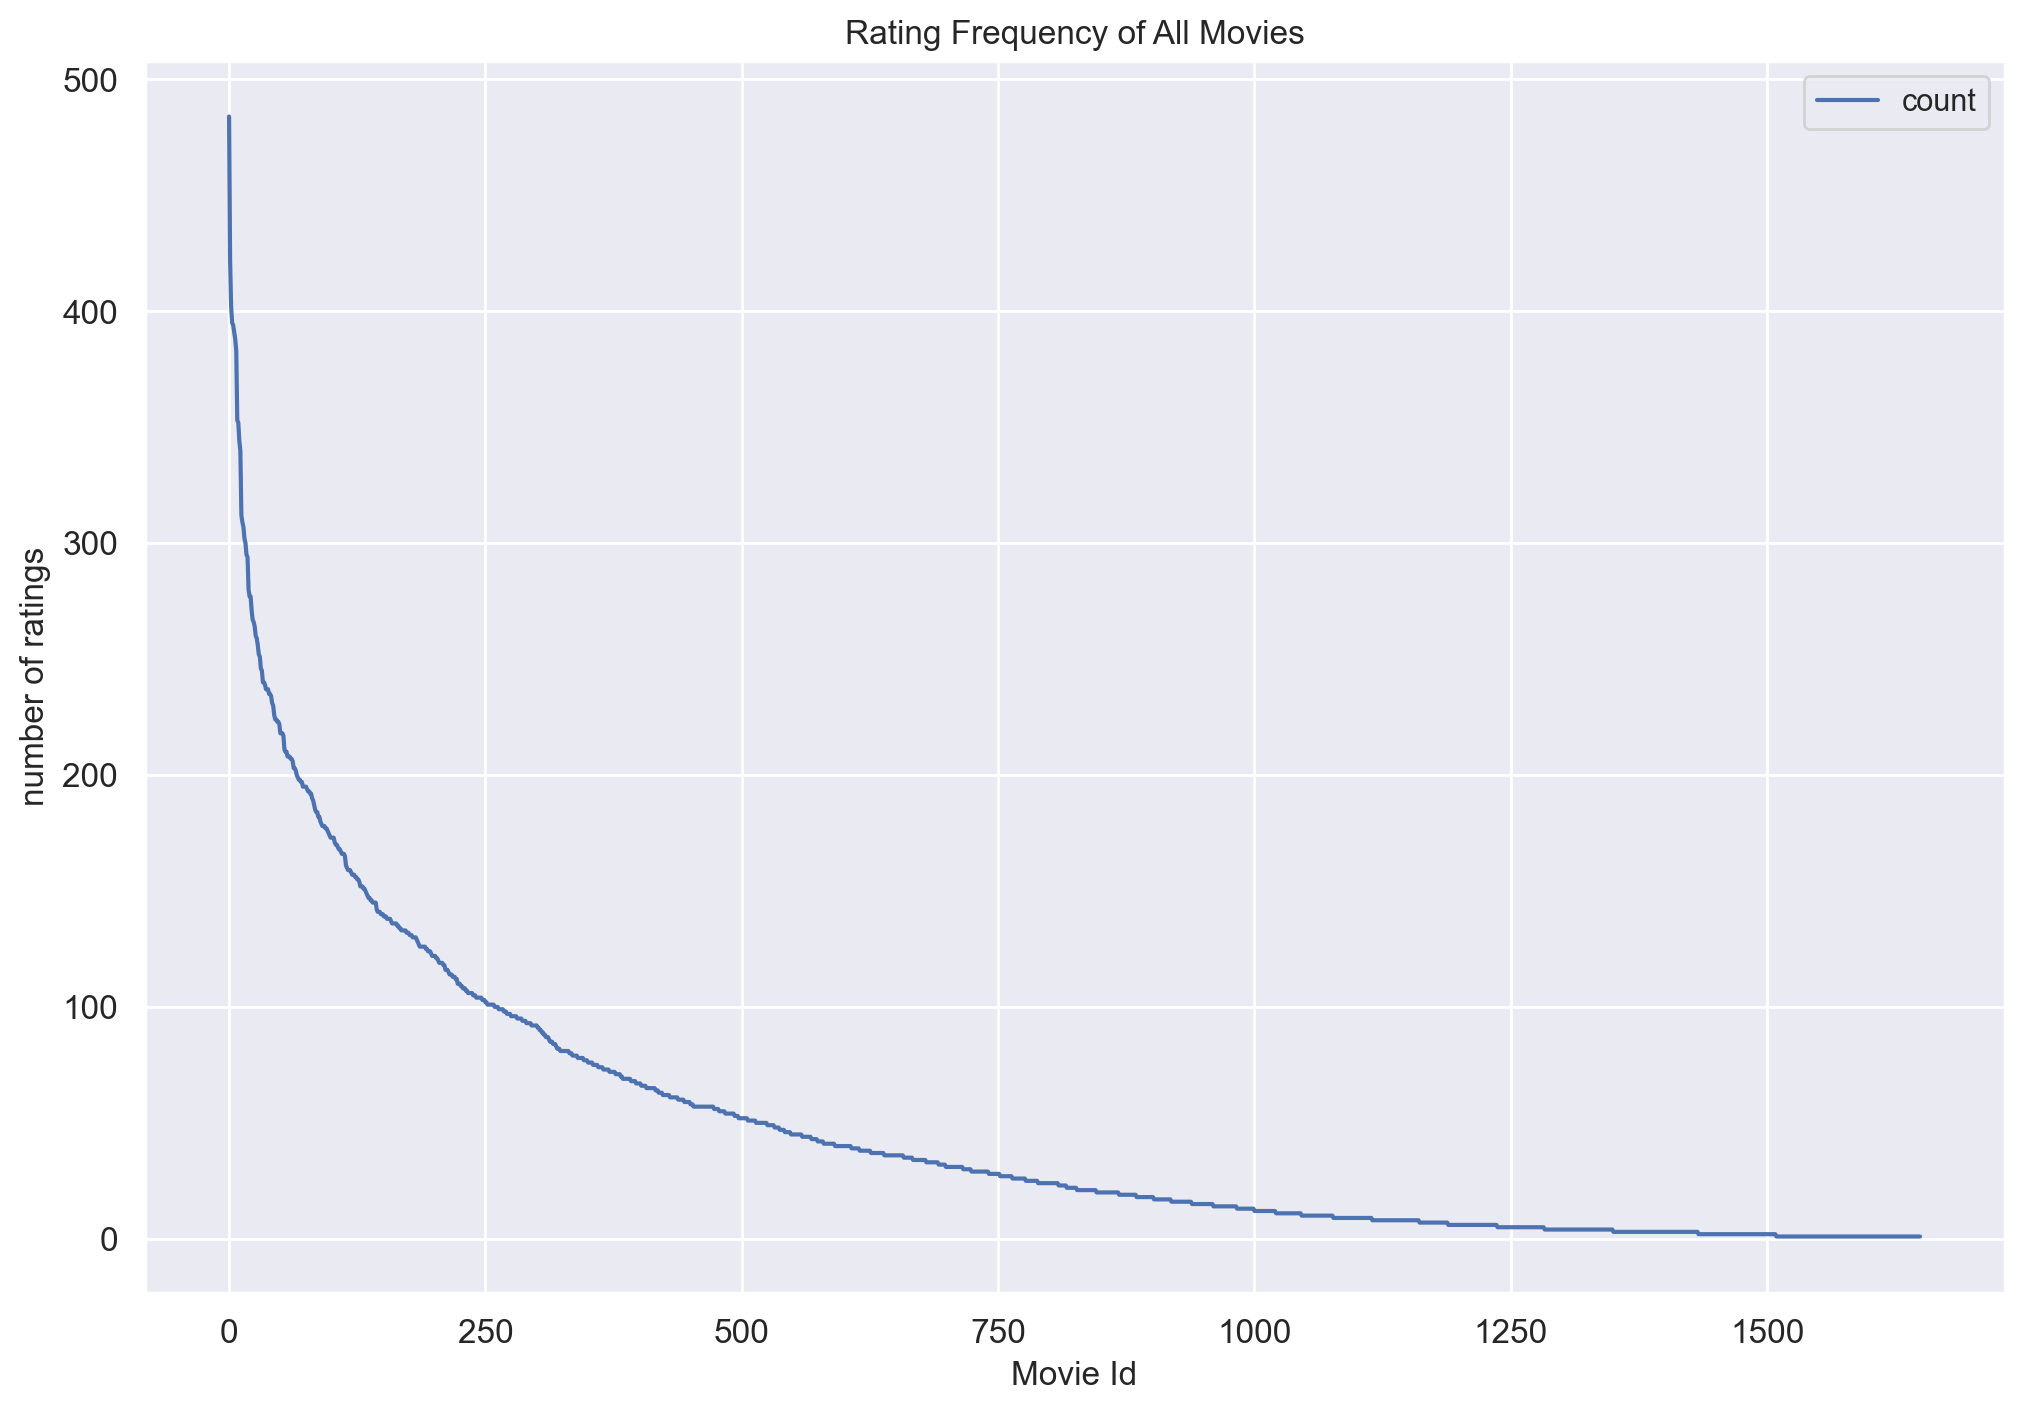

In [85]:
# plot rating frequency of all movies
ax = (
    movie_rat_freq.sort_values("count", ascending=False)
    .reset_index(drop=True)
    .plot(figsize=(12, 8), title="Rating Frequency of All Movies", fontsize=12)
)
ax.set_xlabel("Movie Id")
ax.set_ylabel("number of ratings")

The distribution of ratings among movies often satisfies a property in real-world settings, which is referred to as the _long-tail property_. According to this property, only a small fraction of the items are rated frequently. Such items are referred to as popular items. The vast majority of items are rated rarely. This results in a highly skewed distribution of the underlying ratings.

Let's plot the same distribution but with log scale.

Text(0, 0.5, 'number of ratings (log scale)')

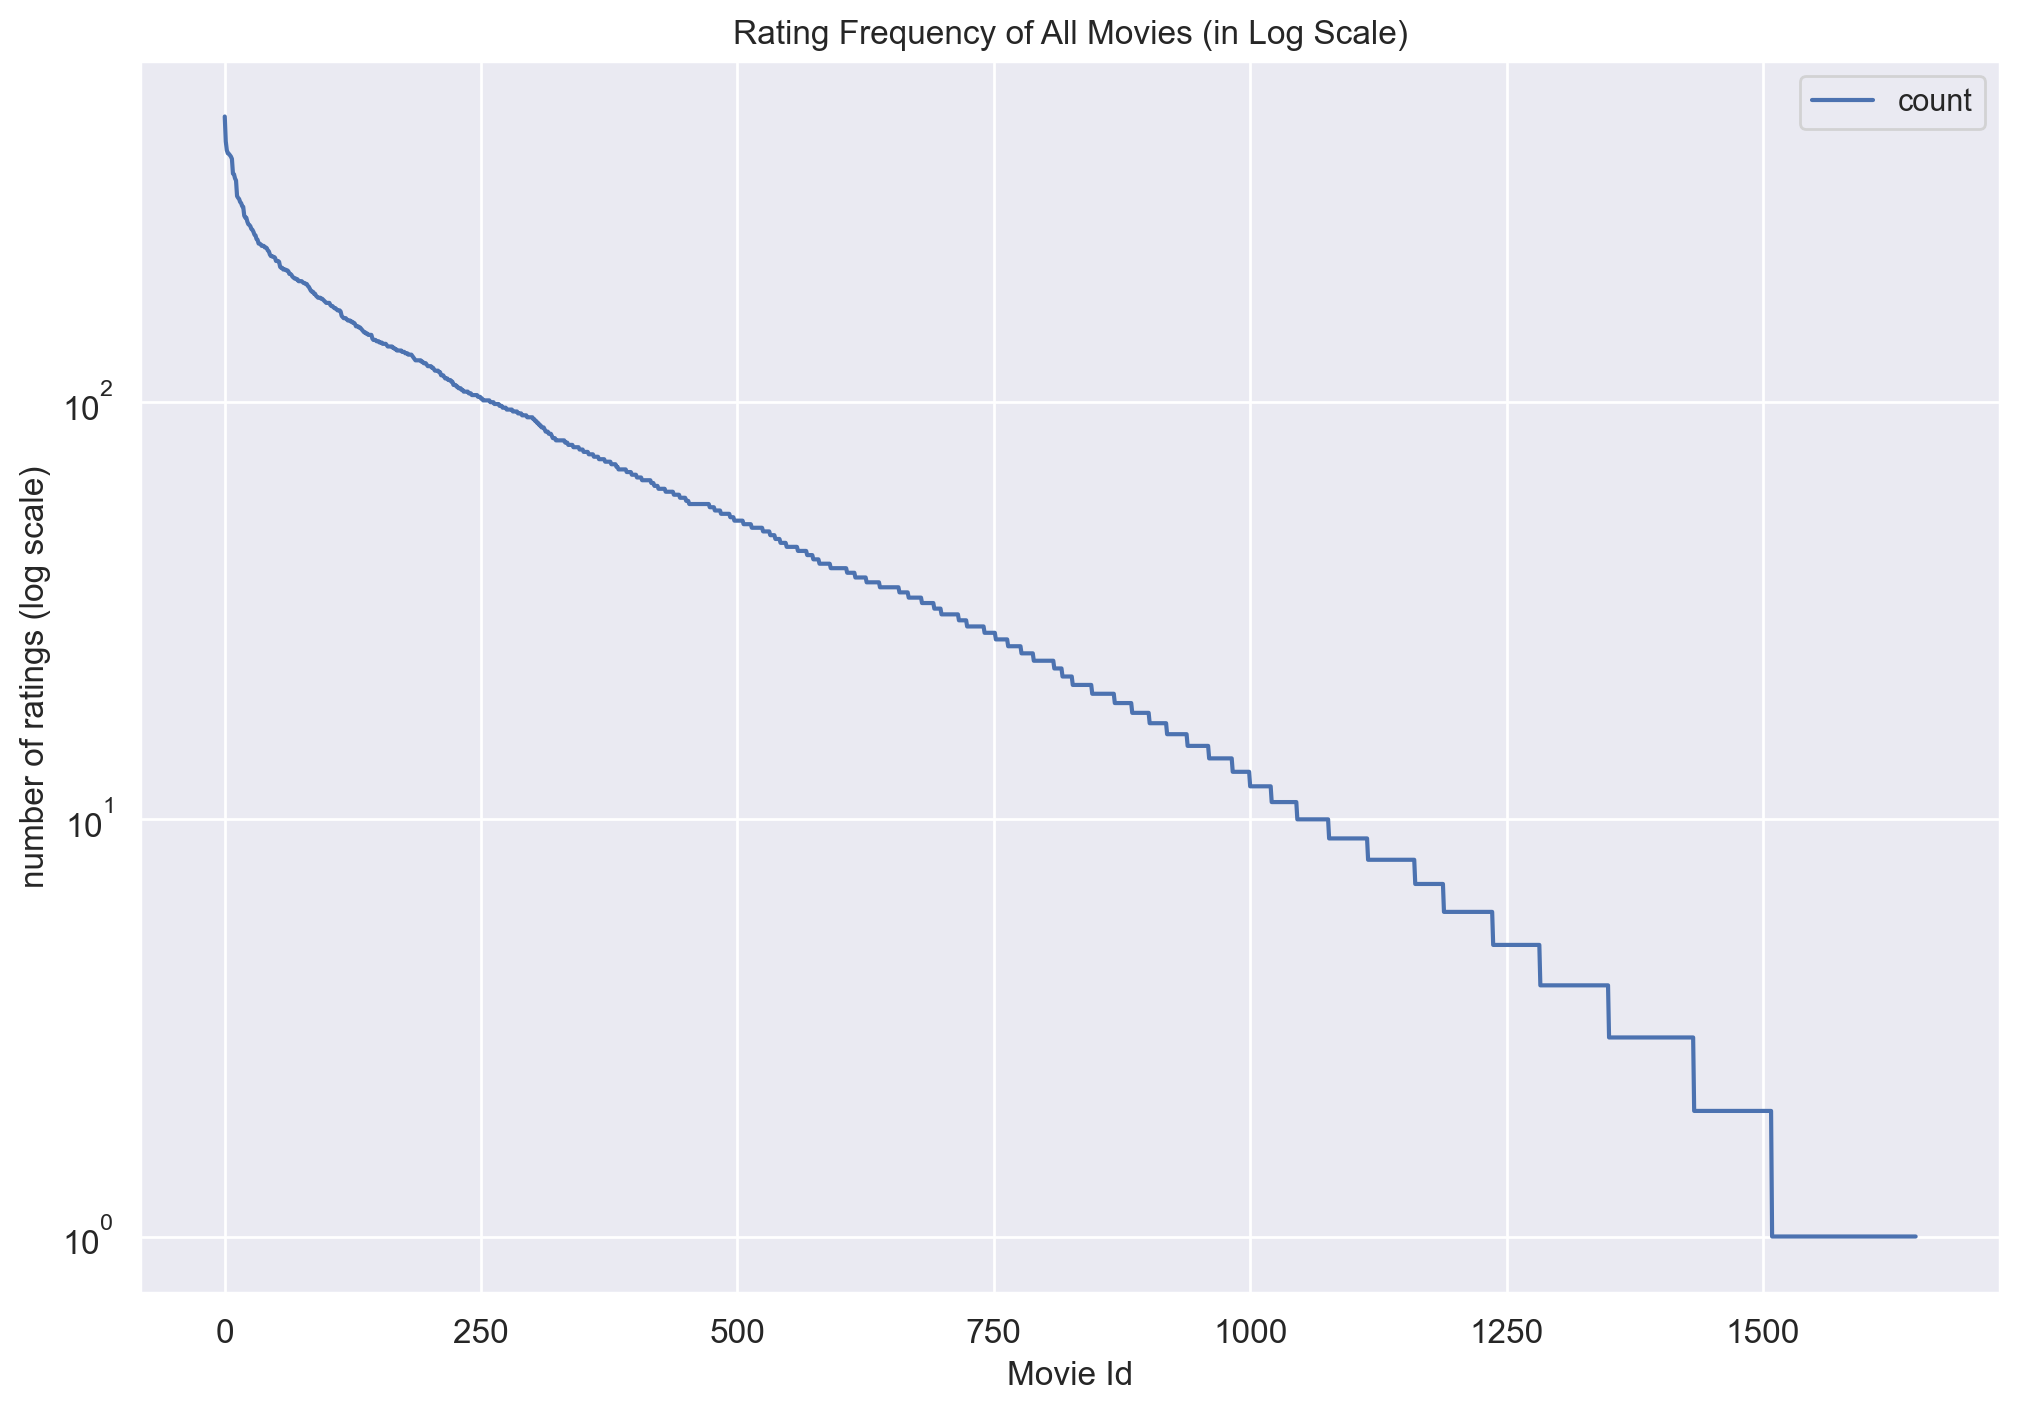

In [86]:
# plot rating frequency of all movies in log scale
ax = (
    movie_rat_freq.sort_values("count", ascending=False)
    .reset_index(drop=True)
    .plot(
        figsize=(12, 8),
        title="Rating Frequency of All Movies (in Log Scale)",
        fontsize=12,
        logy=True,
    )
)
ax.set_xlabel("Movie Id")
ax.set_ylabel("number of ratings (log scale)")

We can see that ~$700$ movies out of $1682$ are rated less than only $10$ times. Let's look closer by displaying top quantiles of rating counts.

In [87]:
movie_rat_freq["count"].quantile(np.arange(1, 0.6, -0.05))

1.00    484.0
0.95    188.1
0.90    135.0
0.85    103.0
0.80     81.0
0.75     65.0
0.70     53.0
0.65     42.0
Name: count, dtype: float64

So about $1\%$ of movies have roughly $484$ or more ratings, $5\%$ have $188$ or more, and $20\%$ have $80$ or more. 

This is an effect of the reduced dataset we have chosen.

Try to import the complete dataset from [movielens](https://grouplens.org/datasets/movielens/) and repeat this very same analysis. 

You will find an even longer tail effect, which leads to the choice of the reduced dataset.

This is convenient for a two-fold reason:

1. Memory issue: we don't want to run into the “MemoryError” during model training
2. Improve model performance: lesser known movies have ratings from fewer viewers, making the pattern more noisy. Dropping out less known movies can improve recommendation quality.

### Explaining Rating Frequency Per Movie & The Long-Tail Property

#### 1️⃣ Why Are We Studying Rating Frequency Per Movie?
In recommender systems, not all movies receive the same number of ratings. Some are extremely popular, while others are rarely rated.

This imbalance can have a major impact on how recommendations are generated:

* Popular movies dominate recommendations.
* Niche movies struggle to get recommended, even if they match user preferences.
* The dataset becomes biased toward mainstream content.

#### 2️⃣ Understanding The Long-Tail Property
**📌 Definition:**

* A few popular movies receive a huge number of ratings.
* Most other movies have very few ratings.
* When plotted, this distribution forms a long-tail shape.

**📌 What Does This Mean?**

* The head (left side of the plot) = Popular movies with many ratings.
* The tail (right side of the plot) = Niche movies with few ratings.
* The dataset is highly skewed → a small fraction of movies dominate the majority of ratings.

**📌 Real-World Examples:**

* On Netflix, a handful of blockbuster movies get most of the attention.
* On Spotify, a few artists dominate global streams, while thousands of indie artists get minimal exposure.

#### 3️⃣ How To Interpret The Log-Scale Plot?

**🔍 Why Use a Log Scale?**
If we plot the raw rating counts, popular movies dominate the graph, making it hard to see the long-tail effect.
A log scale compresses large values, so both popular and rare movies are visible on the same graph.

#### 4️⃣ Why Is The Long-Tail Property Important?
* Popular items dominate recommendations.
* Niche movies struggle to be recommended.
* Users with unique preferences get fewer relevant suggestions.

**👉 Recommender systems must address this issue to improve diversity and personalisation!**

#### 📝 Questions for Students

* How does the long-tail effect impact the quality of recommendations?
* What happens if a recommender system only recommends popular items?
* How could you design a system that recommends more niche movies?
* What are some strategies to balance popularity and diversity in recommendations?

---

#### Rating frequency per user

At this stage, it is useful to study the rating frequency per user.

### Vérification et réponses — effet de longue traîne

Avec le fichier `u1.base` réellement chargé, on trouve **1 650 films notés**. Parmi eux, **573 ont moins de 10 notes**. La moitié des films possède au plus **22 notes**, alors que les 20 % les plus populaires en ont au moins **81**. Les seuils des 5 % et 1 % les plus populaires sont respectivement d'environ **188** et **298** notes. Les valeurs 700, 1 682 et 484 indiquées plus haut ne correspondent donc pas exactement à ce fichier ; elles viennent probablement d'une autre version de MovieLens.

La longue traîne peut diminuer la qualité des prédictions sur les films rares, car le modèle dispose de peu d'exemples. Mais les supprimer entièrement réduit la diversité et pénalise les utilisateurs qui ont des goûts moins courants.

Un système qui recommande seulement les films populaires est rassurant au début, mais il devient vite répétitif. Il crée aussi une boucle : les films déjà visibles reçoivent encore plus de notes, tandis que les autres restent inconnus.

Pour proposer davantage de films de niche, on peut combiner la pertinence avec un score de nouveauté, utiliser les genres pour trouver des films proches mais moins connus, réserver quelques places à l'exploration et exclure les films déjà vus.

Enfin, on peut équilibrer popularité et diversité avec une étape de réorganisation de la liste : par exemple 70 % de recommandations fiables et 30 % de découvertes. Il faut ensuite mesurer non seulement la précision, mais aussi la couverture du catalogue, la diversité, la nouveauté et la sérendipité.

In [88]:
user_rat_freq = pd.DataFrame(df_rating.groupby("UserId").size(), columns=["count"])
user_rat_freq.head()

,count
UserId,
1,135
2,40
3,28
4,14
5,91


Text(0, 0.5, 'number of ratings')

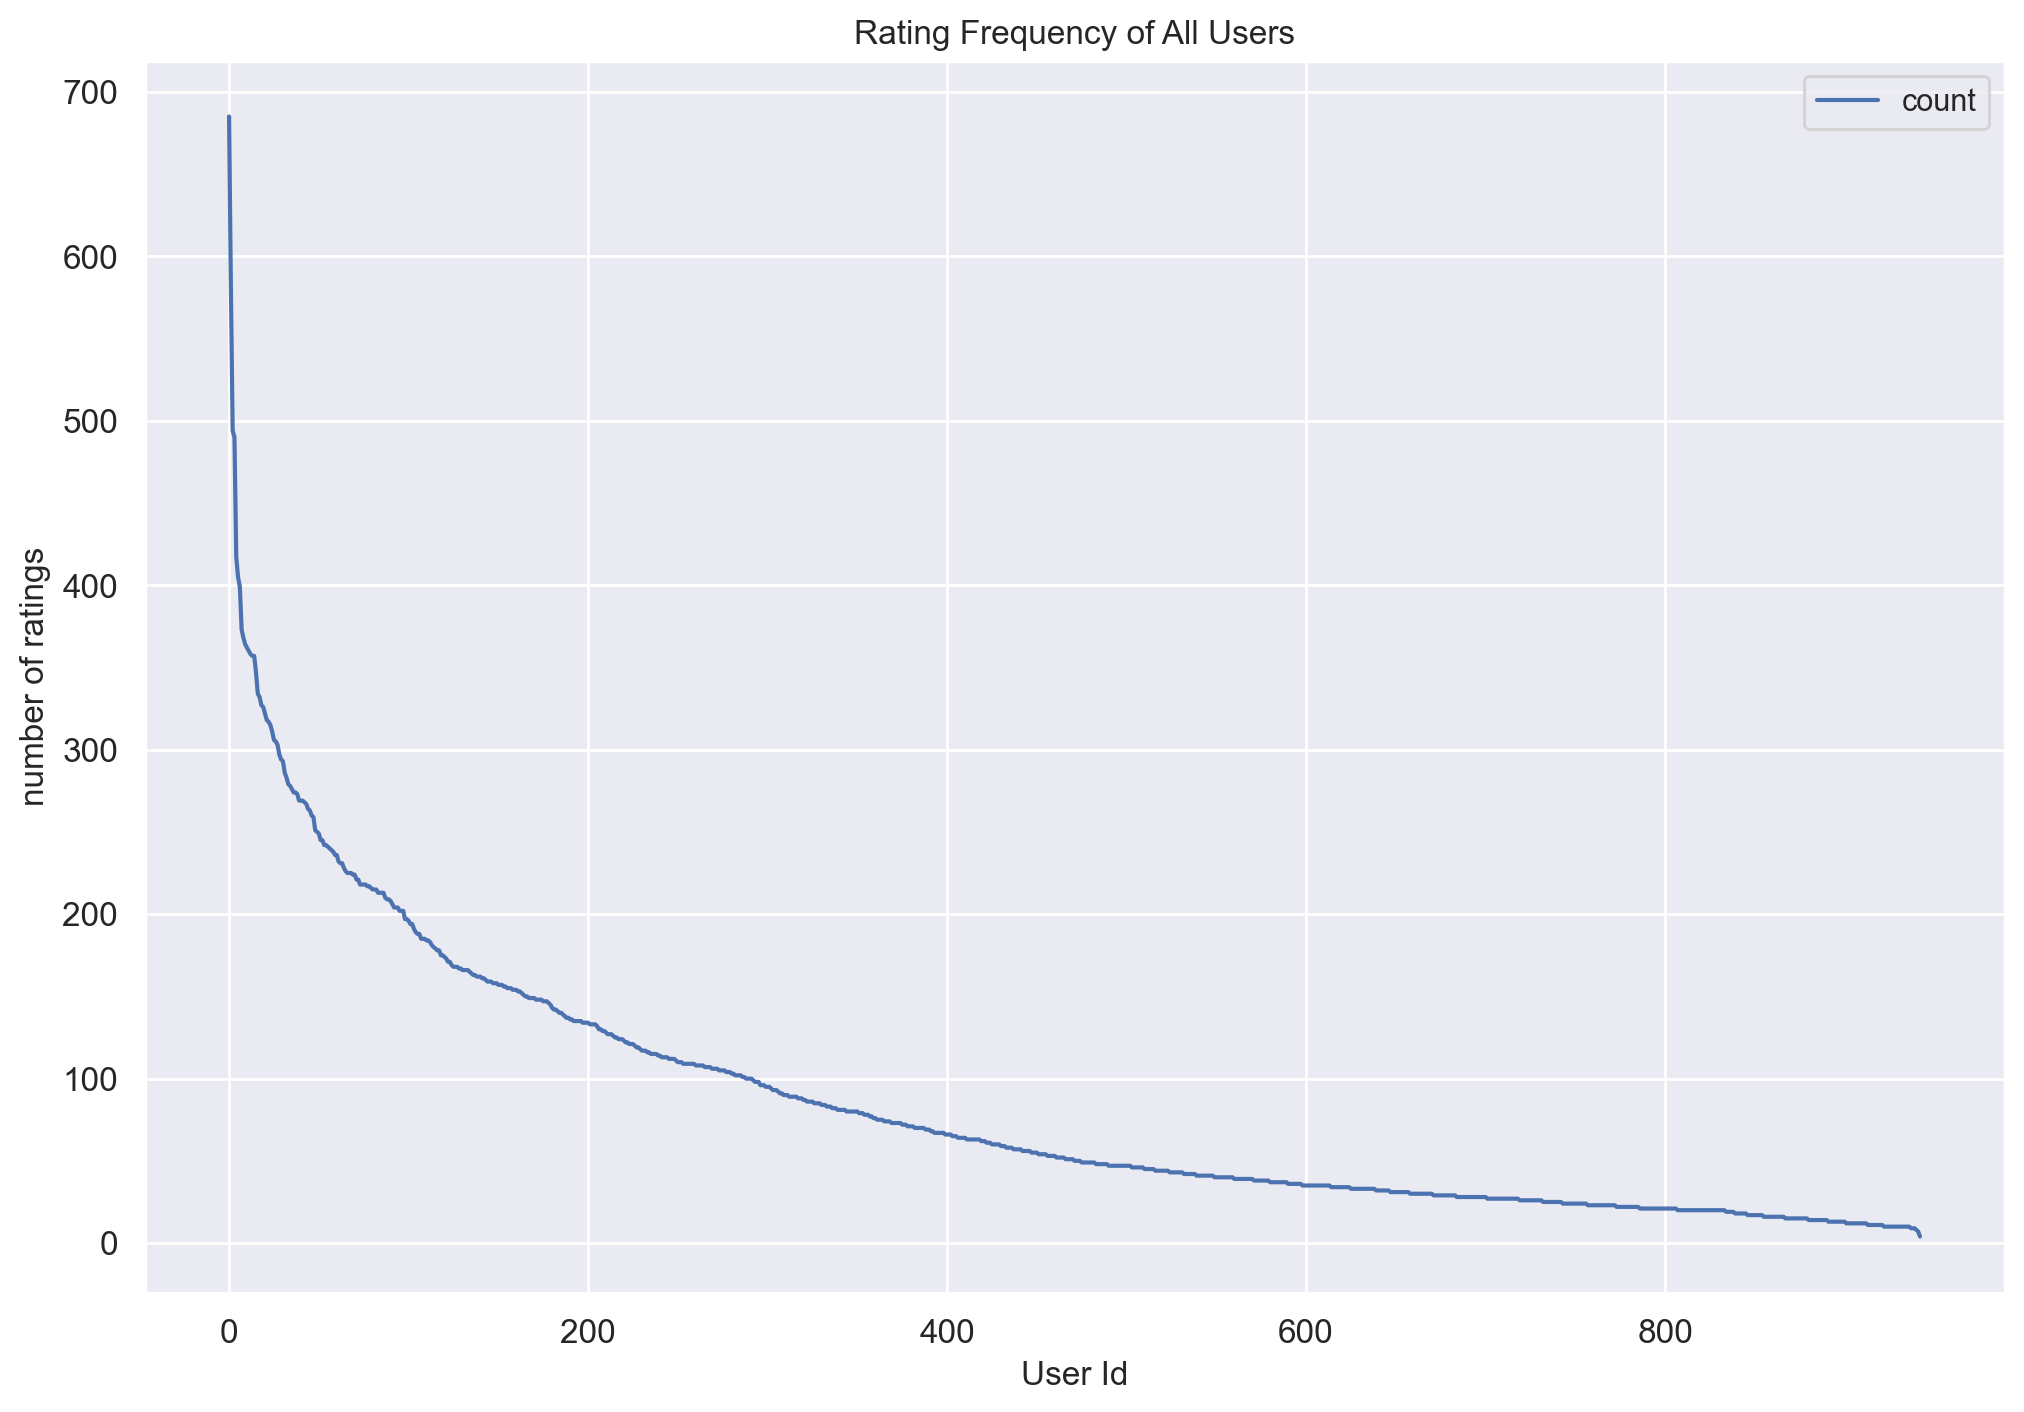

In [89]:
# plot rating frequency of all users
ax = (
    user_rat_freq.sort_values("count", ascending=False)
    .reset_index(drop=True)
    .plot(figsize=(12, 8), title="Rating Frequency of All Users", fontsize=12)
)
ax.set_xlabel("User Id")
ax.set_ylabel("number of ratings")

We can see that the distribution of ratings by users is very similar to the distribution of ratings among movies.
Again, we can see the long-tail effect, less pronounced than in the movie distribution, but still there.

This means that few users give a lot of feedbacks on movies they see (they are called "engaged users"). Indeed, only a very small fraction of users are very actively engaged with rating movies that they watched. Vast majority of users are not interested in rating movies.

In [90]:
user_rat_freq["count"].quantile(np.arange(1, 0.5, -0.05))

1.00    685.0
0.95    258.2
0.90    203.6
0.85    161.0
0.80    137.0
0.75    115.0
0.70    102.0
0.65     84.3
0.60     72.0
0.55     61.0
Name: count, dtype: float64

Text(0, 0.5, 'number of ratings (log scale)')

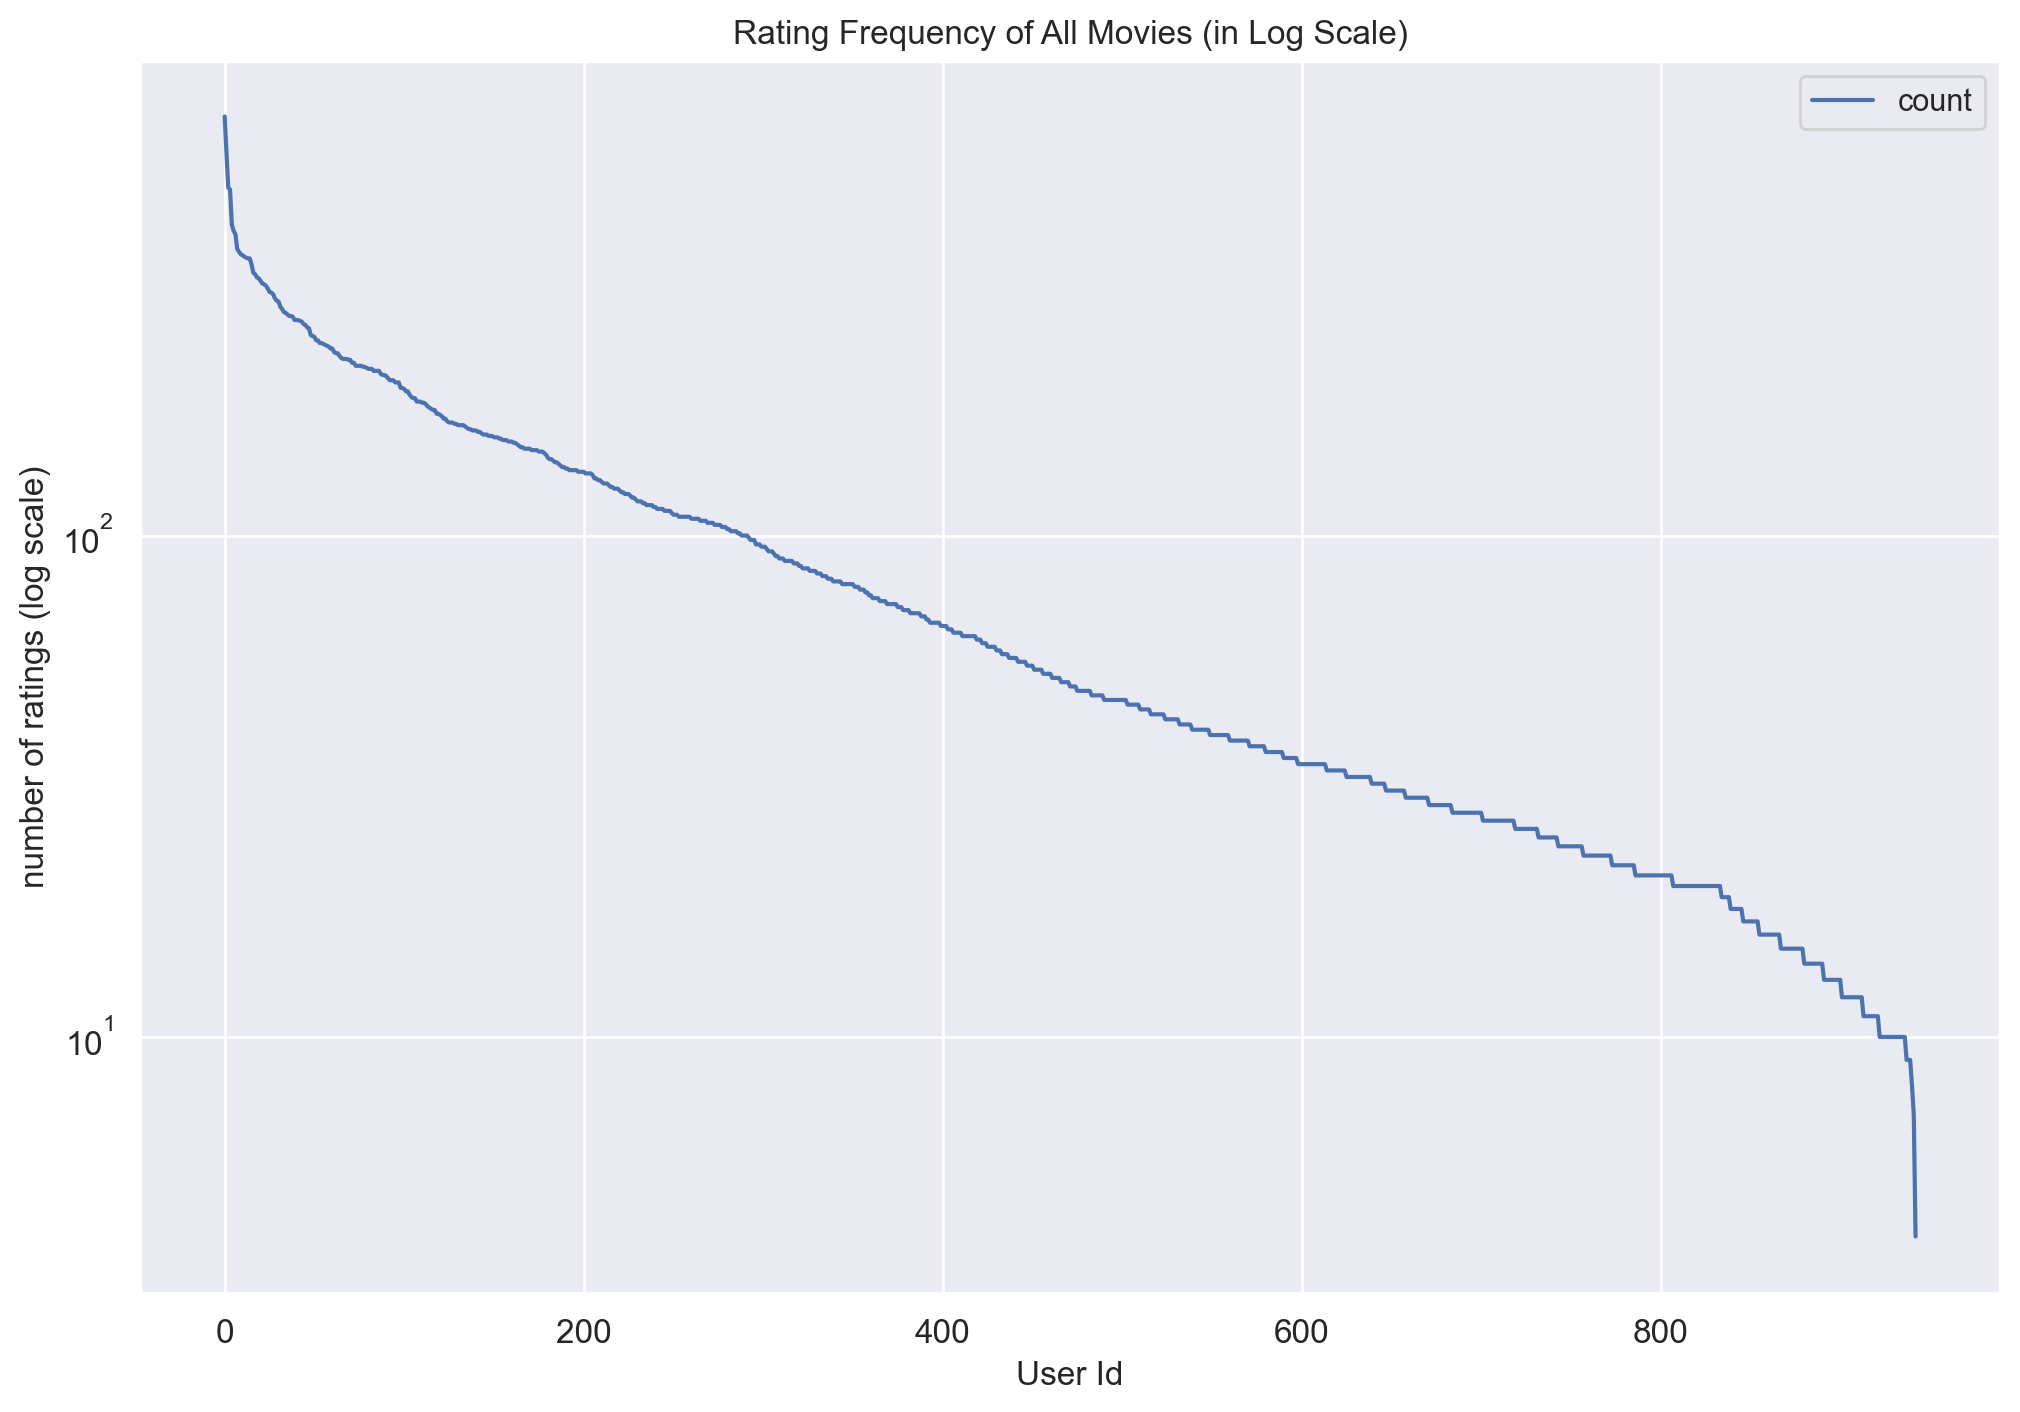

In [91]:
# plot rating frequency of all users in log scale
ax = (
    user_rat_freq.sort_values("count", ascending=False)
    .reset_index(drop=True)
    .plot(
        figsize=(12, 8),
        title="Rating Frequency of All Movies (in Log Scale)",
        fontsize=12,
        logy=True,
    )
)
ax.set_xlabel("User Id")
ax.set_ylabel("number of ratings (log scale)")

#### Exercise

Repeat the very same analysis for the bigger version of the movielens dataset, the one that can be downloaded at [http://files.grouplens.org/datasets/movielens/ml-10m.zip](http://files.grouplens.org/datasets/movielens/ml-10m.zip).

Show that the long-tail effect is much more evident.

### Calculate the most popular movie

Let's look at the movie colums. We can create a vector, summing over the colums, to get a _total score_ measuring how much that movie has been rated.

Thanks to pandas methods, this can be done by one line of code.

In [92]:
movie_scores = df_matrix.sum(axis=0, skipna=True)
movie_scores

MovieId
1       1491.0
2        334.0
3        225.0
4        603.0
5        228.0
         ...  
1678       1.0
1679       3.0
1680       2.0
1681       3.0
1682       3.0
Length: 1650, dtype: float64

Now we need to store the movie score in the corresponding dataframe.
Since the movie score is a pandas series, whose index is the same as the index of the movie dataframe, we can simply add a column as follows.

In [93]:
df_items["score"] = movie_scores
df_items

,Title,Date,VideoReleaseDate,Url,unknown,Action,Adventure,Animation,Children,Comedy,...,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,score
MovieId,,,,,,,,,,,,,,,,,,,,,
1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,1491.0
2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,0,...,0,0,0,0,0,0,1,0,0,334.0
3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,225.0
4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,603.0
5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,228.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1678,Mat' i syn (1997),06-Feb-1998,NaN,http://us.imdb.com/M/title-exact?Mat%27+i+syn+...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.0
1679,B. Monkey (1998),06-Feb-1998,NaN,http://us.imdb.com/M/title-exact?B%2E+Monkey+(...,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,3.0
1680,Sliding Doors (1998),01-Jan-1998,NaN,http://us.imdb.com/Title?Sliding+Doors+(1998),0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,2.0


### Giving recommendations

Hence, we are ready to give recommendations. 

We split the problem into four steps of growing difficulty.

1. We always recommend the most popular movie.
2. We recommend the most popular movie in the same genre of the best rated movie per each user.
3. We look at the last rated movie (whose rating is over 4) for each user and we recommend the most popular movie in the same genre.
4. We do as in $3.$ but with a random distribution, we pick uniformly amongst the first $10$ most popular movies.

#### Most popular movie recommendation

The first point is the easiest one, we only need to look at the movie whose score is the highest one.

In [94]:
df_items.iloc[[df_items.score.argmax()]]

,Title,Date,VideoReleaseDate,Url,unknown,Action,Adventure,Animation,Children,Comedy,...,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,score
MovieId,,,,,,,,,,,,,,,,,,,,,
50,Star Wars (1977),01-Jan-1977,NaN,http://us.imdb.com/M/title-exact?Star%20Wars%2...,0,1,1,0,0,0,...,0,0,0,0,1,1,0,1,0,2110.0


Hence, let's write a recommendation function.

In [95]:
def recommend_one():
    """Function to return the recommendations based on the most popular criterion."""
    return df_items.loc[[df_items.score.argmax() + 1]]

In [96]:
recommend_one()

,Title,Date,VideoReleaseDate,Url,unknown,Action,Adventure,Animation,Children,Comedy,...,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,score
MovieId,,,,,,,,,,,,,,,,,,,,,
50,Star Wars (1977),01-Jan-1977,NaN,http://us.imdb.com/M/title-exact?Star%20Wars%2...,0,1,1,0,0,0,...,0,0,0,0,1,1,0,1,0,2110.0


This function returns just the most popular movie. However, we may want to consider multiple recommendations: hence we want to return the first then movies with the highest popularity score.

In [97]:
def recommend_n(n_recommendations: int = 10) -> pd.DataFrame:
    """Function to return recommendations based on the most popular criterion.
    Parameters
    ----------
    n_recommendations: int
        Number of recommendations to return.
        default: 10

    Returns
    -------
    pd.DataFrame
        The dataframe containing the recommendations in order of preference.
    """
    return df_items.sort_values(by="score", ascending=False).iloc[:n_recommendations]

In [98]:
recommend_n()

,Title,Date,VideoReleaseDate,Url,unknown,Action,Adventure,Animation,Children,Comedy,...,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,score
MovieId,,,,,,,,,,,,,,,,,,,,,
50,Star Wars (1977),01-Jan-1977,NaN,http://us.imdb.com/M/title-exact?Star%20Wars%2...,0,1,1,0,0,0,...,0,0,0,0,1,1,0,1,0,2110.0
181,Return of the Jedi (1983),14-Mar-1997,NaN,http://us.imdb.com/M/title-exact?Return%20of%2...,0,1,1,0,0,0,...,0,0,0,0,1,1,0,1,0,1693.0
100,Fargo (1996),14-Feb-1997,NaN,http://us.imdb.com/M/title-exact?Fargo%20(1996),0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1623.0
258,Contact (1997),11-Jul-1997,NaN,http://us.imdb.com/Title?Contact+(1997/I),0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1537.0
1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,1491.0
174,Raiders of the Lost Ark (1981),01-Jan-1981,NaN,http://us.imdb.com/M/title-exact?Raiders%20of%...,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1461.0
127,"Godfather, The (1972)",01-Jan-1972,NaN,"http://us.imdb.com/M/title-exact?Godfather,%20...",0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1448.0
286,"English Patient, The (1996)",15-Nov-1996,NaN,http://us.imdb.com/M/title-exact?English%20Pat...,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,1413.0
288,Scream (1996),20-Dec-1996,NaN,http://us.imdb.com/M/title-exact?Scream%20(1996),0,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,1347.0


#### Most popular movie in the same genre recommendation

Now we start to include the user history in some sense. This is not personalised, as we never use user features, but we focus on the last movie the user liked in order to make a recommendation about a new movie.

This is a first example of _content based recommendations_.

First, we need to see which movie the user liked most recently. This can be done by looking at the "timestamp" column in rating table.

<details>
    <summary><b>HINT</b></summary> 
    
    You can find the implemented function in the utils module `non_pers_rec.py`. 
    Try to implement the function on your own before looking at the given implementation.
</details>

In [99]:
def get_recent_liked_movie(user_id: int, threshold: float = 4.0) -> int:
    """Function to get the id of the movie that the user has liked most recently.

    Parameters
    ----------
    user_id : int
        The id of the user we are interested in.
    threshold : float
        The rating threshold, to determine whether a user appreciated the movie.
        default: 4.0

    Returns
    -------
    int
        The movie id that the user has liked most recently.
    """
    # Complete the function
    usr_liked_movies = df_rating[
        (df_rating["UserId"] == user_id)
        & (df_rating["Rating"] >= threshold)
    ]

    if usr_liked_movies.empty:
        return recommend_n()

    max_timestamp = usr_liked_movies["Timestamp"].max()
    most_recent = usr_liked_movies[
        usr_liked_movies["Timestamp"] == max_timestamp
    ]
    return int(
        most_recent.sort_values("Rating", ascending=False).iloc[0]["MovieId"]
    )

In [100]:
### Unit tests ###
test_get_recent_liked_movie(get_recent_liked_movie)

 All tests passed.


##### Extract the genre information

The idea is to use the just-found id, to extract the genre information out of the `df_items` dataframe, and then recommend the most popular movies in the same genre.

**Note**: The `df_items` dataframe is multi-hot encoding the genre information, hence a movie can have multiple genres and they are stored as ones in the corresponding columns of the dataframe.

To fix this issue, we define a pandas series populated converting the multi-hot encoding columns into a single column.

In [101]:
genre_cols = [
    "Action",
    "Adventure",
    "Animation",
    "Children",
    "Comedy",
    "Crime",
    "Documentary",
    "Drama",
    "Fantasy",
    "Film-Noir",
    "Horror",
    "Musical",
    "Mystery",
    "Romance",
    "Sci-Fi",
    "Thriller",
    "War",
    "Western",
]


genre_series = df_items[genre_cols].apply(
    lambda row: row[row == 1].index.tolist(), axis=1
)

npr.genre_series = genre_series
genre_series

MovieId
1       [Animation, Children, Comedy]
2       [Action, Adventure, Thriller]
3                          [Thriller]
4             [Action, Comedy, Drama]
5            [Crime, Drama, Thriller]
                    ...              
1678                          [Drama]
1679              [Romance, Thriller]
1680                 [Drama, Romance]
1681                         [Comedy]
1682                          [Drama]
Length: 1682, dtype: object

Once the list of genres has been used to create the corresponding column, we can extract such information passing the movie id.

In [102]:
def get_genre(movie_id: int) -> List[str]:
    """Function to get the genre of the inserted movie.

    Parameters
    ----------
    movie_id : int
        The id of the movie whose genre is to be returned.

    Returns
    -------
    list of str
        the genres of the inserted movie.
    """

    # Complete the function
    return genre_series.loc[movie_id]

In [103]:
### Unit tests ###
test_get_movie_genre(get_genre)

 All tests passed.


At this stage, we need to make a choice. 
In particular, we have to decide how to handle the case where one movie is classified in more than one genre.

Our choice is the following:
> If a movie has more than one genre, then we take the most popular movies in all the genres appearing in the list.

Let's write a code to recommend the first $n$ movies in the genre of the last positively evaluated movie.

In [104]:
def recommend_genre_n(
    n_recommendations: int = 10, genres: List[str] = None
) -> pd.DataFrame:
    """Function to return recommendations based on the most popular criterion in a given genre list.
    Parameters
    ----------
    n_recommendations: int
        Number of recommendations to return.
        default: 10
    genres: List of strings
        The list of genres in which to return the recommendations.
        If not provided, the function will return the recommendations based on all genres.
        default: None

    Returns
    -------
    pd.DataFrame
        The dataframe containing the recommendations in order of preference.
    """

    if genres is not None:
        # Filter movies by genre
        mask = df_items[genres].eq(1).all(axis=1)
        return (
            df_items[mask]
            .sort_values(by="score", ascending=False)
            .iloc[:n_recommendations]
        )
    else:
        return recommend_n(n_recommendations=n_recommendations)

Let's make sure that the function works as expected.

In [105]:
# Call on all the genres.
recommend_genre_n()

,Title,Date,VideoReleaseDate,Url,unknown,Action,Adventure,Animation,Children,Comedy,...,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,score
MovieId,,,,,,,,,,,,,,,,,,,,,
50,Star Wars (1977),01-Jan-1977,NaN,http://us.imdb.com/M/title-exact?Star%20Wars%2...,0,1,1,0,0,0,...,0,0,0,0,1,1,0,1,0,2110.0
181,Return of the Jedi (1983),14-Mar-1997,NaN,http://us.imdb.com/M/title-exact?Return%20of%2...,0,1,1,0,0,0,...,0,0,0,0,1,1,0,1,0,1693.0
100,Fargo (1996),14-Feb-1997,NaN,http://us.imdb.com/M/title-exact?Fargo%20(1996),0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1623.0
258,Contact (1997),11-Jul-1997,NaN,http://us.imdb.com/Title?Contact+(1997/I),0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1537.0
1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,1491.0
174,Raiders of the Lost Ark (1981),01-Jan-1981,NaN,http://us.imdb.com/M/title-exact?Raiders%20of%...,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1461.0
127,"Godfather, The (1972)",01-Jan-1972,NaN,"http://us.imdb.com/M/title-exact?Godfather,%20...",0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1448.0
286,"English Patient, The (1996)",15-Nov-1996,NaN,http://us.imdb.com/M/title-exact?English%20Pat...,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,1413.0
288,Scream (1996),20-Dec-1996,NaN,http://us.imdb.com/M/title-exact?Scream%20(1996),0,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,1347.0


In [106]:
genres = ["Crime", "Drama"]

recommend_genre_n(genres=genres)

,Title,Date,VideoReleaseDate,Url,unknown,Action,Adventure,Animation,Children,Comedy,...,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,score
MovieId,,,,,,,,,,,,,,,,,,,,,
100,Fargo (1996),14-Feb-1997,NaN,http://us.imdb.com/M/title-exact?Fargo%20(1996),0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1623.0
127,"Godfather, The (1972)",01-Jan-1972,NaN,"http://us.imdb.com/M/title-exact?Godfather,%20...",0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1448.0
56,Pulp Fiction (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?Pulp%20Fictio...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1252.0
187,"Godfather: Part II, The (1974)",01-Jan-1974,NaN,http://us.imdb.com/M/title-exact?Godfather:%20...,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,736.0
182,GoodFellas (1990),01-Jan-1990,NaN,http://us.imdb.com/M/title-exact?GoodFellas%20...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,698.0
403,Batman (1989),01-Jan-1989,NaN,http://us.imdb.com/M/title-exact?Batman%20(1989),0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,553.0
293,Donnie Brasco (1997),28-Feb-1997,NaN,http://us.imdb.com/M/title-exact?Donnie%20Bras...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,494.0
327,Cop Land (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?Cop+Land+(1997),0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,469.0
628,Sleepers (1996),18-Oct-1996,NaN,http://us.imdb.com/M/title-exact?Sleepers%20(1...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,466.0


**Excercise** 

What is missing at this stage is a function combining the work we have done above such that given a user id, we can have recommendations based on what the user liked more recently. 
_Writing such a function is left as an exercise._

Be sure to handle the case of a new user, _e.g._ a user_id that is not in the database.
There is no need to write a lot of code, try to use the functions we defined above.

Here is an example docstring written for you.

```python
def get_recommendations(user_id: int) -> pd.DataFrame:
    """Function to get recommendations for a user identified by its user_id.
    These are in the same genres as the most recently liked movie.

    Parameters
    ----------
    user_id : int
        The id of the user for whom recommendations are generated.
    
    Returns
    -------
    pd.DataFrame
        The recommendations for the given user, in the form of a pd.DataFrame.
    """
```

---

#### Picking recommendations from a distribution

Finally, we can use a strategy to randomly pick recommendations out of a distribution.

Indeed, we do not want to recommend movies always in order of score, but sometimes, it is more efficient to pick randomly out of a bucket of movies.

To do so, we only need to modify the function above as follows.


In [107]:
def get_recommendations(
    user_id: int, n_recommendations: int = 10
) -> pd.DataFrame:
    """Return popular recommendations in the genres of the last liked movie."""
    if user_id not in df_rating["UserId"].values:
        return recommend_n(n_recommendations)

    recent_movie = get_recent_liked_movie(user_id)
    if not isinstance(recent_movie, (int, np.integer)):
        return recommend_n(n_recommendations)

    genres = get_genre(recent_movie)
    return recommend_genre_n(
        n_recommendations=n_recommendations, genres=genres
    )

In [108]:
def recommend_genre_n(
    n_recommendations: int = 10, genres: List[str] = None, temp: float = 1.0
) -> pd.DataFrame:
    """Function to return recommendations based on the most popular criterion in a given genre list.
    Parameters
    ----------
    n_recommendations: int
        Number of recommendations to return.
        default: 10
    genres: List of strings
        The list of genres in which to return the recommendations.
        If not provided, the function will return the recommendations based on all genres.
        default: None
    temp: float
        Parameter setting the randomness of the recommendations. The higher is the temperature, more random is the recommendation.
        default: 1.0

    Returns
    -------
    pd.DataFrame
        The dataframe containing the recommendations in order of preference.
    """

    if genres is not None:
        # Filter movies by genre
        mask = df_items[genres].eq(1).all(axis=1)
        df_recommend = (
            df_items[mask]
            .sort_values(by="score", ascending=False)
            .iloc[:n_recommendations]
        )
    else:
        df_recommend = recommend_n(n_recommendations=n_recommendations)

    # Define and normalise vector of probabilities
    probs = [np.exp(-i / temp) for i in range(len(df_recommend))]
    probs = np.array(probs) / np.sum(probs)

    rnd_indices = np.random.choice(
        df_recommend.index, n_recommendations, p=probs, replace=False
    )
    return df_recommend.loc[rnd_indices]

In [109]:
# Let's verify that the recommendations order changes with temperature.
display(recommend_genre_n(temp=10))
display(recommend_genre_n(temp=2))
display(recommend_genre_n(temp=200))

,Title,Date,VideoReleaseDate,Url,unknown,Action,Adventure,Animation,Children,Comedy,...,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,score
MovieId,,,,,,,,,,,,,,,,,,,,,
127,"Godfather, The (1972)",01-Jan-1972,NaN,"http://us.imdb.com/M/title-exact?Godfather,%20...",0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1448.0
258,Contact (1997),11-Jul-1997,NaN,http://us.imdb.com/Title?Contact+(1997/I),0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1537.0
1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,1491.0
50,Star Wars (1977),01-Jan-1977,NaN,http://us.imdb.com/M/title-exact?Star%20Wars%2...,0,1,1,0,0,0,...,0,0,0,0,1,1,0,1,0,2110.0
181,Return of the Jedi (1983),14-Mar-1997,NaN,http://us.imdb.com/M/title-exact?Return%20of%2...,0,1,1,0,0,0,...,0,0,0,0,1,1,0,1,0,1693.0
174,Raiders of the Lost Ark (1981),01-Jan-1981,NaN,http://us.imdb.com/M/title-exact?Raiders%20of%...,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1461.0
300,Air Force One (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?Air+Force+One...,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1287.0
100,Fargo (1996),14-Feb-1997,NaN,http://us.imdb.com/M/title-exact?Fargo%20(1996),0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1623.0
286,"English Patient, The (1996)",15-Nov-1996,NaN,http://us.imdb.com/M/title-exact?English%20Pat...,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,1413.0


,Title,Date,VideoReleaseDate,Url,unknown,Action,Adventure,Animation,Children,Comedy,...,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,score
MovieId,,,,,,,,,,,,,,,,,,,,,
50,Star Wars (1977),01-Jan-1977,NaN,http://us.imdb.com/M/title-exact?Star%20Wars%2...,0,1,1,0,0,0,...,0,0,0,0,1,1,0,1,0,2110.0
181,Return of the Jedi (1983),14-Mar-1997,NaN,http://us.imdb.com/M/title-exact?Return%20of%2...,0,1,1,0,0,0,...,0,0,0,0,1,1,0,1,0,1693.0
258,Contact (1997),11-Jul-1997,NaN,http://us.imdb.com/Title?Contact+(1997/I),0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1537.0
1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,1491.0
174,Raiders of the Lost Ark (1981),01-Jan-1981,NaN,http://us.imdb.com/M/title-exact?Raiders%20of%...,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1461.0
100,Fargo (1996),14-Feb-1997,NaN,http://us.imdb.com/M/title-exact?Fargo%20(1996),0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1623.0
286,"English Patient, The (1996)",15-Nov-1996,NaN,http://us.imdb.com/M/title-exact?English%20Pat...,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,1413.0
127,"Godfather, The (1972)",01-Jan-1972,NaN,"http://us.imdb.com/M/title-exact?Godfather,%20...",0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1448.0
288,Scream (1996),20-Dec-1996,NaN,http://us.imdb.com/M/title-exact?Scream%20(1996),0,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,1347.0


,Title,Date,VideoReleaseDate,Url,unknown,Action,Adventure,Animation,Children,Comedy,...,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,score
MovieId,,,,,,,,,,,,,,,,,,,,,
100,Fargo (1996),14-Feb-1997,NaN,http://us.imdb.com/M/title-exact?Fargo%20(1996),0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1623.0
288,Scream (1996),20-Dec-1996,NaN,http://us.imdb.com/M/title-exact?Scream%20(1996),0,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,1347.0
258,Contact (1997),11-Jul-1997,NaN,http://us.imdb.com/Title?Contact+(1997/I),0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1537.0
286,"English Patient, The (1996)",15-Nov-1996,NaN,http://us.imdb.com/M/title-exact?English%20Pat...,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,1413.0
174,Raiders of the Lost Ark (1981),01-Jan-1981,NaN,http://us.imdb.com/M/title-exact?Raiders%20of%...,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1461.0
181,Return of the Jedi (1983),14-Mar-1997,NaN,http://us.imdb.com/M/title-exact?Return%20of%2...,0,1,1,0,0,0,...,0,0,0,0,1,1,0,1,0,1693.0
1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,1491.0
300,Air Force One (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?Air+Force+One...,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1287.0
50,Star Wars (1977),01-Jan-1977,NaN,http://us.imdb.com/M/title-exact?Star%20Wars%2...,0,1,1,0,0,0,...,0,0,0,0,1,1,0,1,0,2110.0


#### Further exercises

Try to write a test function that outputs the recommendations for an user that recently liked "the Godfather part 1".

* Verify that the other two movies of the Godfather saga are present in the recommendations.
* Slightly modify the code above in order to exclude a movie the user has already seen and evaluated.


### Exercise: Serendipity-Based Recommendations

💡 Goal: Instead of recommending only popular or highly rated movies, we want to surprise the user with relevant but unexpected content.

#### 1️⃣ What Is Serendipity in Recommendations?
**Serendipity** means finding something valuable that you weren’t actively looking for.

If a system only recommends mainstream content, it lacks serendipity.
A good recommender balances relevance (does the user like it?) and novelty (is it unexpected?).

**✅ Example of High Serendipity:**

A user who watches Marvel movies gets recommended a hidden gem from an indie sci-fi director.

**🚫 Example of Low Serendipity:**

A user who watches "The Avengers" gets recommended "Iron Man 3" (too obvious).

---

#### 2️⃣ Serendipity-Based Recommendation Strategy

**👉 Approach: Mix popular and underexplored content while ensuring relevance.**

🔹 Step 1: Start With a Standard Recommendation List

Generate recommendations using Collaborative Filtering (CF) or Content-Based Filtering (CBF).

Example: Suppose CF recommends these movies for a user:
* 🎬 The Dark Knight
* 🎬 Inception
* 🎬 Interstellar

🔹 Step 2: Identify Underexplored (Low-Popularity) Movies

Find movies similar to highly rated ones but with fewer total ratings.

Example: Instead of just recommending blockbusters, we add:
* 🎬 Predestination (a lesser-known time-travel movie).
* 🎬 Coherence (a mind-bending indie sci-fi film).

🔹 Step 3: Inject Serendipity Into the Recommendation List

Diversify recommendations by blending:
✅ Popular movies (high confidence, high ratings).
✅ Hidden gems (movies with good user satisfaction but lower visibility).

*Final Recommendation List:*

* 🎬 The Dark Knight (Popular)
* 🎬 Inception (Popular)
* 🎬 Coherence (Hidden gem)
* 🎬 Interstellar (Popular)
* 🎬 Predestination (Hidden gem)

---

### 3️⃣ Code Exercise: Serendipity-Based Movie Recommendation

Write the code to implement the serendipity based recommender described above.

In [110]:
# Insert your code here
def recommend_serendipitous(
    user_id: int,
    n_recommendations: int = 10,
    hidden_gem_ratio: float = 0.3,
    random_state: int = 42,
) -> pd.DataFrame:
    """Mix relevant popular movies with less exposed, well-rated movies."""
    if n_recommendations <= 0:
        return df_items.iloc[0:0].copy()
    if not 0 <= hidden_gem_ratio <= 1:
        raise ValueError("hidden_gem_ratio must be between 0 and 1")

    candidates = df_items.copy()
    if user_id in df_rating["UserId"].values:
        recent_movie = get_recent_liked_movie(user_id)
        if isinstance(recent_movie, (int, np.integer)):
            liked_genres = get_genre(recent_movie)
            if liked_genres:
                relevant_mask = candidates[liked_genres].eq(1).any(axis=1)
                candidates = candidates[relevant_mask]

        watched_movies = df_rating.loc[
            df_rating["UserId"] == user_id, "MovieId"
        ]
        candidates = candidates.drop(index=watched_movies, errors="ignore")

    movie_statistics = df_rating.groupby("MovieId")["Rating"].agg(
        rating_count="count", mean_rating="mean"
    )
    candidates = candidates.join(movie_statistics).dropna(
        subset=["rating_count", "mean_rating"]
    )

    n_hidden = int(round(n_recommendations * hidden_gem_ratio))
    popularity_limit = candidates["rating_count"].quantile(0.5)
    hidden_pool = candidates[
        (candidates["rating_count"] <= popularity_limit)
        & (candidates["mean_rating"] >= candidates["mean_rating"].mean())
    ]
    hidden_movies = hidden_pool.sample(
        n=min(n_hidden, len(hidden_pool)), random_state=random_state
    )

    n_popular = n_recommendations - len(hidden_movies)
    popular_movies = (
        candidates.drop(index=hidden_movies.index)
        .sort_values("score", ascending=False)
        .head(n_popular)
    )
    recommendations = pd.concat([popular_movies, hidden_movies])
    return recommendations.sample(frac=1, random_state=random_state)